# Plot_spectra_Resazurin_and_Resorufin

Google Colab notebook for pH-dependent resazurin and resorufin spectra. Each curve uses the approximate sRGB colour calculated from its absorbance spectrum.

In [1]:
#@title Install and import required packages
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {'numpy': 'numpy', 'pandas': 'pandas', 'matplotlib': 'matplotlib', 'colour-science': 'colour', 'requests': 'requests'}
missing = [package for package, module in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module) is None]
if missing:
    print('Installing:', ', '.join(missing))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', *missing])
else:
    print('All required packages are already installed.')

from base64 import b64encode
from io import BytesIO
from pathlib import Path
import re
import colour
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import numpy as np
import pandas as pd
import requests
from IPython.display import HTML, display
from google.colab import files


Installing: colour-science


In [2]:
#@title Figure settings
FONT_SIZE = 12 #@param {type:"number"}
FONT_TYPE = 'Serif' #@param ["Serif", "Sans-serif", "Monospace"]
LINEWIDTH = 1.0 #@param {type:"number"}
DOWNLOAD_WIDTH_CM = 15.0 #@param {type:"number"}
DOWNLOAD_DPI = 300 #@param {type:"integer"}
DOWNLOAD_PNG = True #@param {type:"boolean"}

RESAZURIN_URL = 'https://raw.githubusercontent.com/postnicov/ResazurinResorufin/refs/heads/main/Data/pHRzSpectra.csv'
RESORUFIN_URL = 'https://raw.githubusercontent.com/postnicov/ResazurinResorufin/refs/heads/main/Data/pHRfSpectra.csv'
OUTPUT_NAME = 'FigRzRfSpectra.png'

font_family = {'Serif': 'serif', 'Sans-serif': 'sans-serif', 'Monospace': 'monospace'}[FONT_TYPE]
math_fontset = {'Serif': 'dejavuserif', 'Sans-serif': 'dejavusans', 'Monospace': 'custom'}[FONT_TYPE]
mpl.rcParams.update({'font.family': font_family, 'font.size': FONT_SIZE, 'axes.labelsize': FONT_SIZE, 'axes.titlesize': FONT_SIZE, 'xtick.labelsize': FONT_SIZE * 0.85, 'ytick.labelsize': FONT_SIZE * 0.85, 'legend.fontsize': FONT_SIZE * 0.80, 'mathtext.fontset': math_fontset, 'mathtext.rm': font_family, 'mathtext.it': f'{font_family}:italic', 'mathtext.bf': f'{font_family}:bold'})
axis_font = FontProperties(family=font_family, size=FONT_SIZE)
tick_font = FontProperties(family=font_family, size=FONT_SIZE * 0.85)
legend_font = FontProperties(family=font_family, size=FONT_SIZE * 0.80)
print(f'Download size: {DOWNLOAD_WIDTH_CM} cm at {DOWNLOAD_DPI} dpi. The notebook preview is fitted to the available screen area.')


Download size: 15.0 cm at 300 dpi. The notebook preview is fitted to the available screen area.


In [3]:
#@title Define data-import and spectrum-to-sRGB functions
def download_spectral_table(url):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    table = pd.read_csv(BytesIO(response.content), header=None)
    if table.shape[0] < 2 or table.shape[1] < 2:
        raise ValueError('Input table must contain a pH row and at least one spectrum.')
    wavelength_all = pd.to_numeric(table.iloc[1:, 0], errors='coerce').to_numpy(float)
    valid_wavelength = np.isfinite(wavelength_all)
    spectra = []
    for column in range(1, table.shape[1]):
        header = str(table.iloc[0, column]).strip()
        match = re.search(r'[-+]?\d*\.?\d+', header)
        ph = match.group(0) if match else header
        absorbance_all = pd.to_numeric(table.iloc[1:, column], errors='coerce').to_numpy(float)
        valid = valid_wavelength & np.isfinite(absorbance_all)
        if valid.sum() >= 2:
            spectra.append((ph, wavelength_all[valid], absorbance_all[valid]))
    if not spectra:
        raise ValueError('No valid absorbance spectra found.')
    return spectra

def absorbance_to_srgb(wavelength_nm, absorbance):
    order = np.argsort(wavelength_nm)
    wavelength_nm = np.asarray(wavelength_nm, float)[order]
    transmittance = np.clip(10.0 ** (-np.asarray(absorbance, float)[order]), 0.0, 1.0)
    spectrum = colour.SpectralDistribution(dict(zip(wavelength_nm, transmittance)))
    spectrum = spectrum.copy().align(colour.SpectralShape(360, 830, 1))
    xyz = colour.sd_to_XYZ(spectrum, cmfs=colour.MSDS_CMFS['CIE 1931 2 Degree Standard Observer'], illuminant=colour.SDS_ILLUMINANTS['D65'])
    return tuple(np.clip(colour.XYZ_to_sRGB(xyz / 100.0), 0.0, 1.0))

def ph_sort_key(spectrum):
    try:
        return float(spectrum[0])
    except ValueError:
        return float('inf')

def display_whole_figure(path):
    """Fit the complete figure to either the cell width or viewport height."""
    encoded = b64encode(Path(path).read_bytes()).decode('ascii')
    style = 'display:block; max-width:100%; max-height:78vh; width:auto; height:auto; object-fit:contain; margin:0 auto;'
    display(HTML(f'<img src="data:image/png;base64,{encoded}" style="{style}">'))



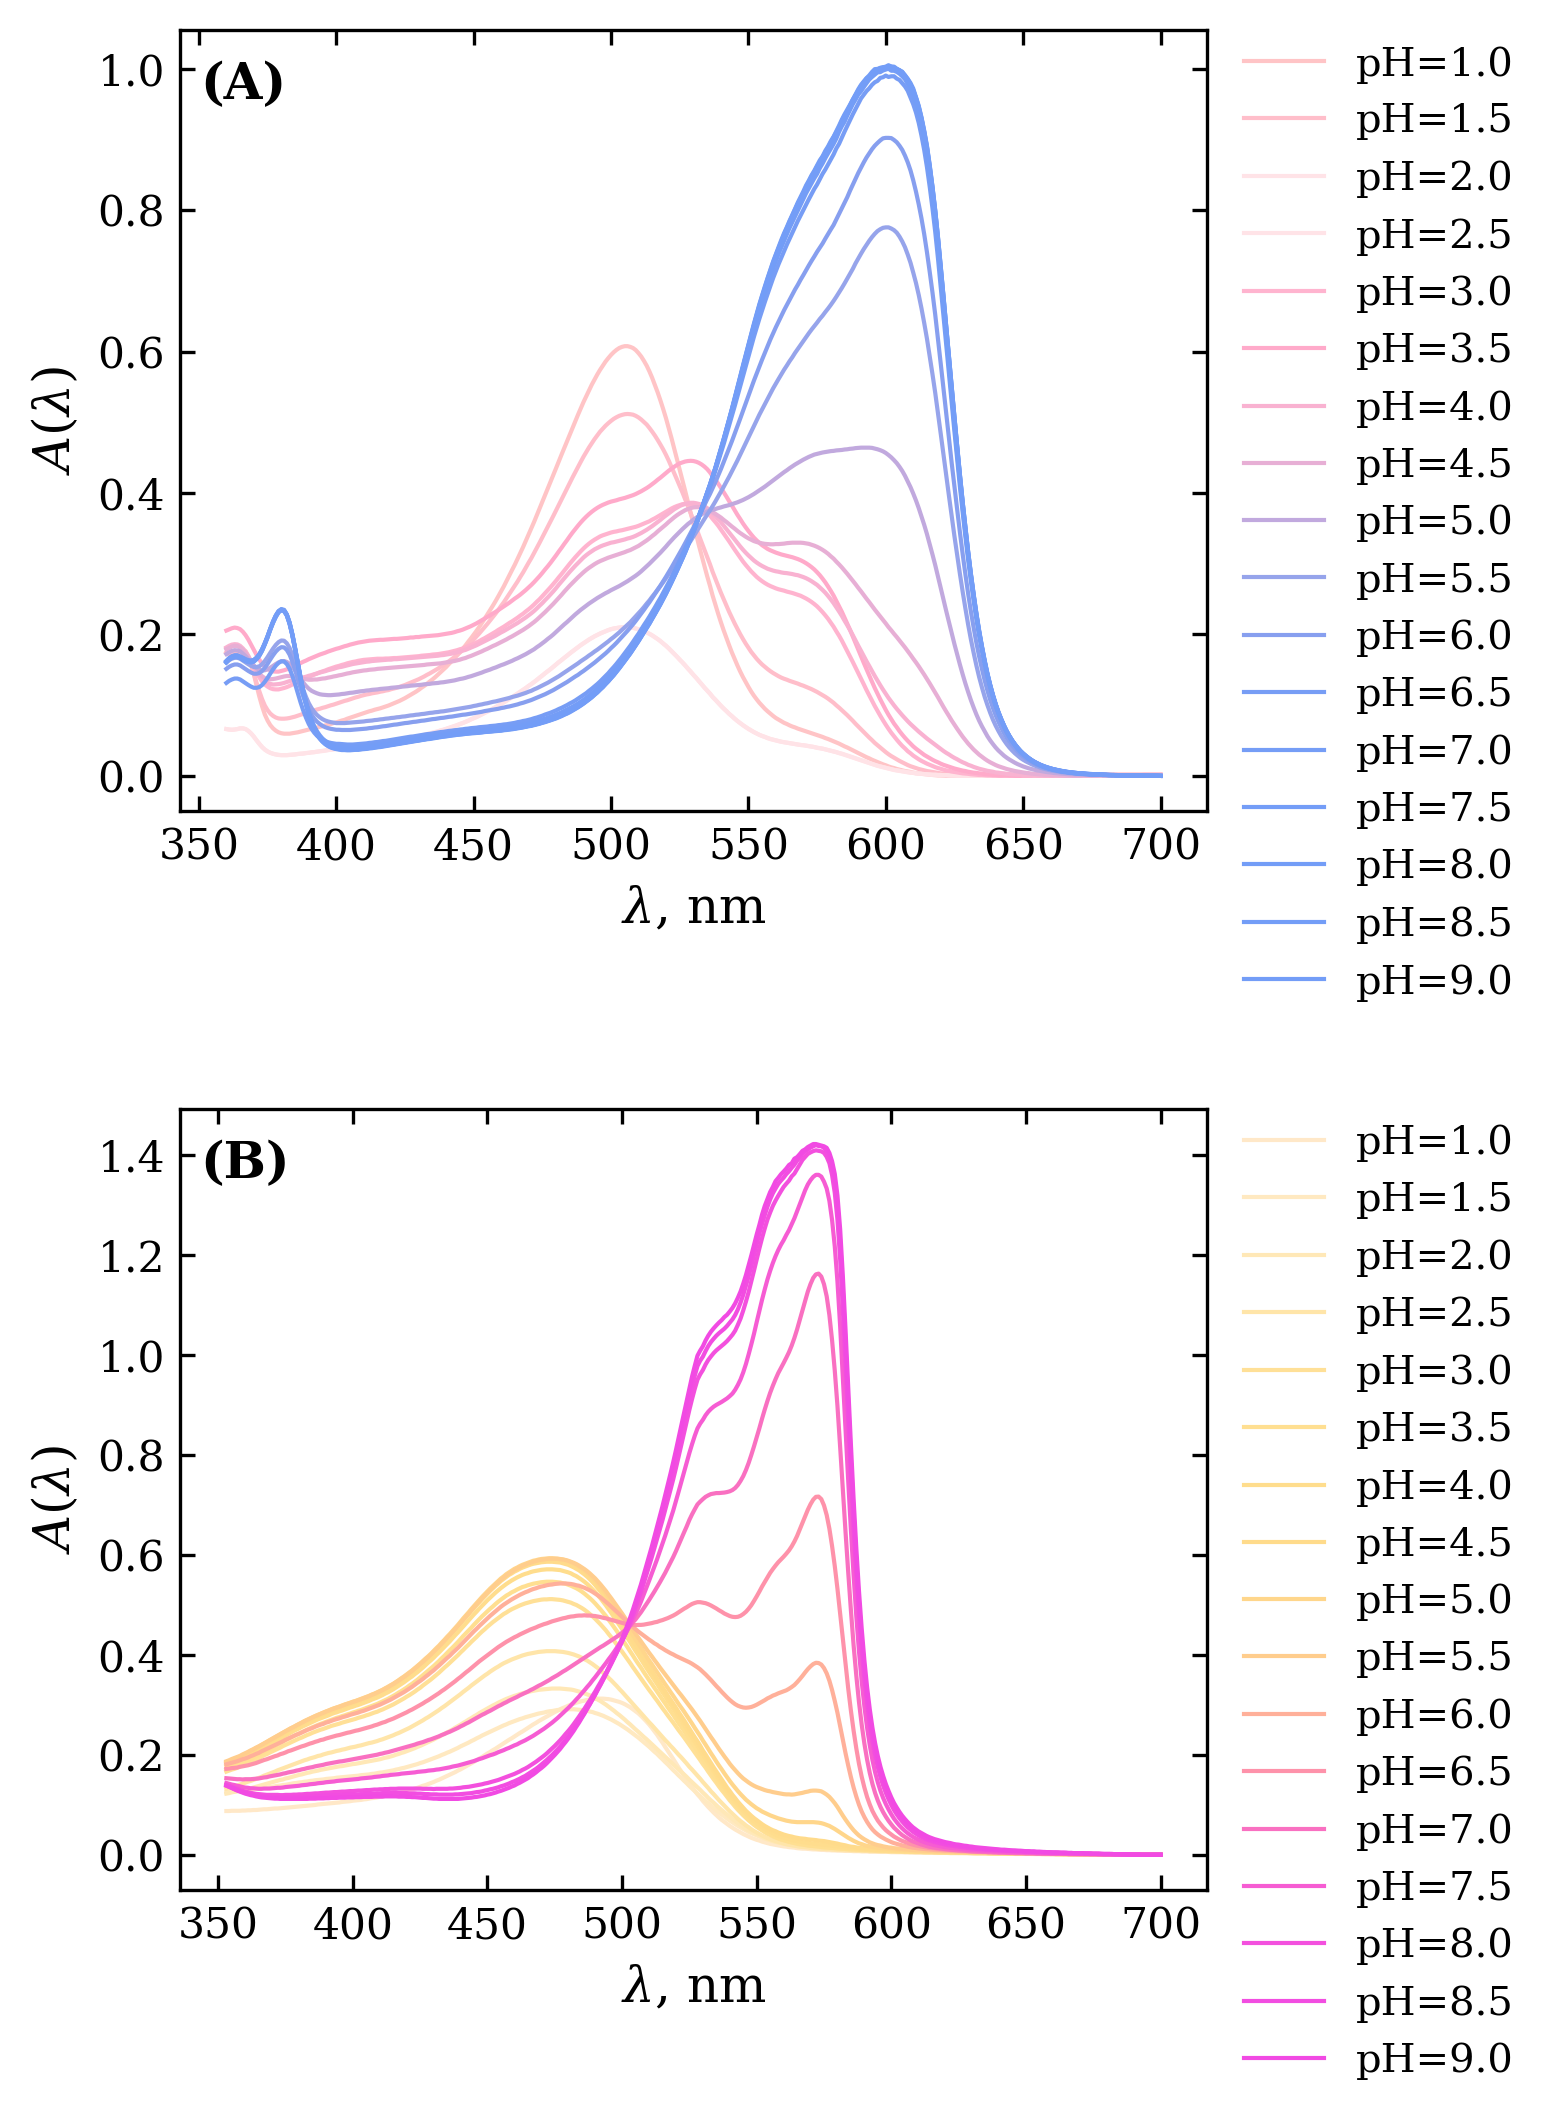

Download PNG saved: /content/Resazurin_and_Resorufin_spectra.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
#@title Create the vertical figure and optionally download its PNG
resazurin = sorted(download_spectral_table(RESAZURIN_URL), key=ph_sort_key)
resorufin = sorted(download_spectral_table(RESORUFIN_URL), key=ph_sort_key)

# These physical dimensions affect only the exported PNG. The display below is automatically scaled for the screen.
export_width_in = DOWNLOAD_WIDTH_CM / 2.54
fig, axes = plt.subplots(2, 1, figsize=(export_width_in, export_width_in * 1.18), dpi=DOWNLOAD_DPI)
fig.subplots_adjust(left=0.14, right=0.72, bottom=0.08, top=0.97, hspace=0.38)

for ax, spectra, panel in zip(axes, (resazurin, resorufin), ('(A)', '(B)')):
    for ph, wavelength, absorbance in spectra:
        rgb = absorbance_to_srgb(wavelength, absorbance)
        ax.plot(wavelength, absorbance, color=rgb, linewidth=LINEWIDTH, label=f'pH={ph}')
    ax.set_xlabel(r'$\lambda$, nm', fontproperties=axis_font)
    ax.set_ylabel(r'$A(\lambda)$', fontproperties=axis_font)
    ax.text(0.02, 0.96, panel, transform=ax.transAxes, ha='left', va='top', fontproperties=axis_font, fontweight='bold')
    ax.tick_params(direction='in', top=True, right=True, width=LINEWIDTH * 0.8)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(tick_font)
    for spine in ax.spines.values():
        spine.set_linewidth(LINEWIDTH * 0.8)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0, frameon=False, prop=legend_font)

output_path = Path('/content') / OUTPUT_NAME
fig.savefig(output_path, dpi=DOWNLOAD_DPI, bbox_inches='tight', facecolor='white')
plt.close(fig)
display_whole_figure(output_path)
print(f'Download PNG saved: {output_path}')
if DOWNLOAD_PNG:
    files.download(str(output_path))
